# Второе Домашнее задание

 №10.9.3. 
 Решить уравнение Релея $$d²x/dt² - μ(1 - (dx/dt)²)(dx/dt) + x = 0$$

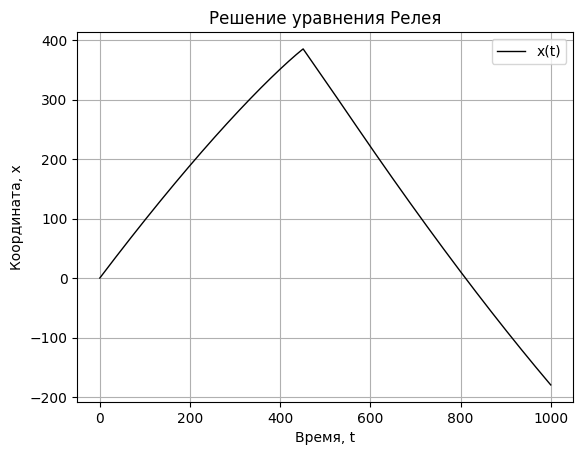

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rayleigh_eq(v, mu):
    """
    Задаём уравнение Релея
    """
    return np.array([v[1], mu * (1 - v[1]**2) * v[1] - v[0]])

def solve_rayleigh(y0, mu, T, dt):
    """
    Численное интегрирование уравнения Релея методом Рунге-Кутты 4-го порядка
    """
    n = int(T / dt) + 1
    y = np.zeros((n, 2))
    y[0] = y0
    for i in range(1, n):
        v = y[i-1]
        k1 = rayleigh_eq(v, mu)
        k2 = rayleigh_eq(v + (dt/2) * k1, mu)
        k3 = rayleigh_eq(v + (dt/2) * k2, mu)
        k4 = rayleigh_eq(v + dt * k3, mu)
        y[i] = v + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
    return y

y_res = solve_rayleigh(np.array([0.0, 0.001]), 1000, 1000, 0.001)
t = np.linspace(0, 1000, len(y_res))

plt.plot(t, y_res[:, 0], linewidth=1, color='black', label='x(t)')
plt.xlabel('Время, t')
plt.ylabel('Координата, x')
plt.title('Решение уравнения Релея')
plt.legend()
plt.grid(True)
plt.show()

*Получили функцию, являющуюся решением ур-я Релея при параметре нелинейности μ = 1000*

№11.3 Решается краевая задача $$y''(x) = -x * \sqrt(y(x))$$ с граничными условиями: y(0) = 0, y(1) = 2

alpha = 1.8429538328076844
y values array:
[0.00000000e+00 1.84295384e-03 3.68590772e-03 ... 1.99520811e+00
 1.99760333e+00 1.99999996e+00]

x values array:
[0.    0.001 0.002 ... 0.998 0.999 1.   ]


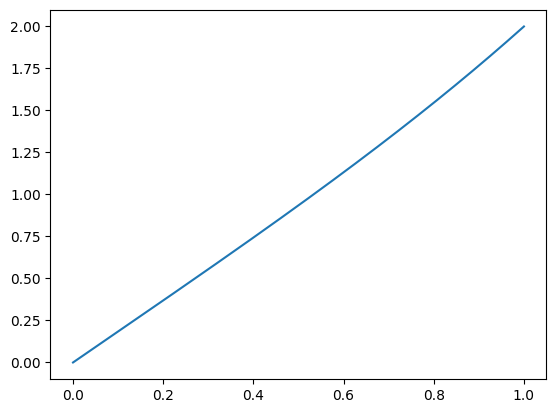

In [9]:
import numpy as np
import matplotlib.pyplot as plt
def shooting_system(x, z, params):
    """
    Массивы правых частей
    """
    y, v, p, q = z[0], z[1], z[2], z[3]
    if y < 0:
        sqrt_y = 0
        dsqrt_dy = 0
    else:
        sqrt_y = np.sqrt(y)
        if y > 1e-12:
            dsqrt_dy = 1.0 / (2.0 * sqrt_y)
        else:
            dsqrt_dy = 0
    
    y_prime = v
    v_prime = x * sqrt_y
    df_dv = 0
    df_dy = -x * dsqrt_dy
    
    p_prime = q
    q_prime = -df_dv * q - df_dy * p
    
    return np.array([y_prime, v_prime, p_prime, q_prime])

def rk4_step(f, x, z, h, params):
    """
    Шаг РК
    """
    k1 = f(x, z, params)
    k2 = f(x + h/2, z + h*k1/2, params)
    k3 = f(x + h/2, z + h*k2/2, params)
    k4 = f(x + h, z + h*k3, params)
    
    return z + h * (k1 + 2*k2 + 2*k3 + k4) / 6


def solve_shooting(alpha, n_steps=100):
    """
    Шаг в методе пристрелки
    """
    x = 0
    h = 1.0 / n_steps
    z = np.array([0.0, alpha, 0.0, 1.0])
    
    for i in range(n_steps):
        z = runge_kutta_step(shooting_system, x, z, h, None)
        x += h

    return z[0], z[2]


def shooting_method(tol=1e-9, max_iter=100):
    """
    Сам метод пристрелки
    """
    alpha = 1.0
    
    for i in range(max_iter):
        y_end, p_end = solve_shooting(alpha)
        
        r = y_end - 2.0
        
        if abs(r) < tol:
            print(f"alpha = {alpha}")
            return alpha
            
        alpha = alpha - r / p_end
    return alpha

def get_solution(alpha, n_steps=1000):
    x = 0
    h = 1.0 / n_steps
    xs = np.linspace(0, 1, n_steps + 1)
    ys = np.zeros(n_steps + 1)
    z = np.array([0.0, alpha, 0.0, 1.0])
    
    ys[0] = z[0]
    for i in range(n_steps):
        z = rk4_step(shooting_system, x, z, h, None)
        x += h
        ys[i+1] = z[0]
    
    return xs, ys

optimal_alpha = shooting_method()
xs, ys = get_solution(optimal_alpha, n_steps=1000)
print(f"y values array:\n{ys}")
print(f"\nx values array:\n{xs}")
plt.plot(xs, ys)
plt.show()

№ T3. Решить краевую задачу $$ y''(x) + g(x)·y'(x) + h(x)·y(x) = f(x)$$
с граничными условиями: y(0) = 0, y(π) = pi**2

Шаг сетки: 0.1013
Количество точек: 32
Границы: [0.0, 3.141592653589793]

Решение системы методом прогонки...

Решение в целевых точках:
x =  0.5 | y =     0.670243 | (точка сетки: 0.5067)
x =  1.0 | y =     2.206662 | (точка сетки: 1.0134)
x =  1.5 | y =     3.922793 | (точка сетки: 1.5201)
x =  2.0 | y =     5.546050 | (точка сетки: 2.0268)
x =  2.5 | y =     7.612407 | (точка сетки: 2.5335)
x =  3.0 | y =     9.355026 | (точка сетки: 3.0403)


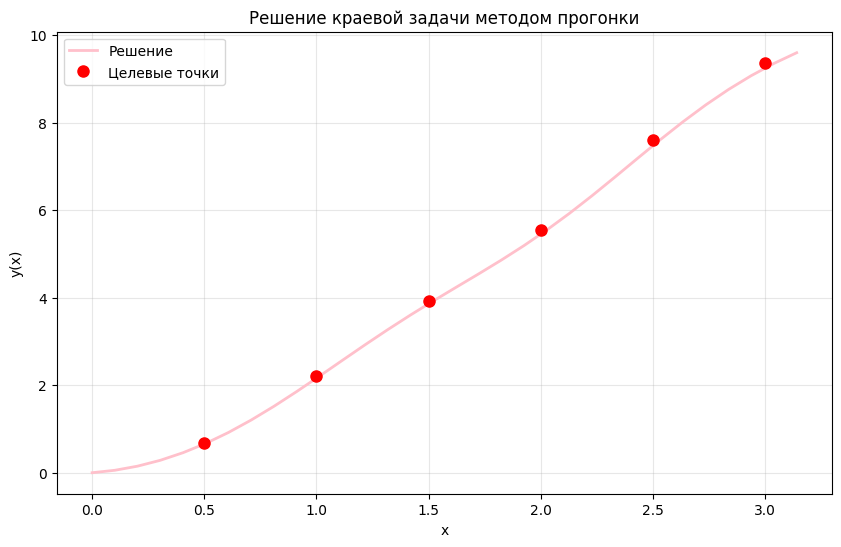

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def thomas_algorithm(a, b, c, d):
    """Алгоритм Томаса"""
    n = len(d)
    
    # Прогоночные коэффициенты
    alpha = np.zeros(n)
    beta = np.zeros(n)
    x = np.zeros(n)
    
    # Прямой ход
    alpha[0] = -c[0] / b[0]
    beta[0] = d[0] / b[0]
    
    for i in range(1, n-1):
        determinant = b[i] + a[i] * alpha[i-1]
        alpha[i] = -c[i] / determinant
        beta[i] = (d[i] - a[i] * beta[i-1]) / determinant
    
    # Обратный ход
    x[n-1] = (d[n-1] - a[n-1] * beta[n-2]) / (b[n-1] + a[n-1] * alpha[n-2])
    
    for i in range(n-2, -1, -1):
        x[i] = alpha[i] * x[i+1] + beta[i]
    
    return x

def f(x: np.ndarray) -> np.ndarray:
    """Правая часть дифференциального уравнения"""
    return 2 - 6*x + 2*x**3 + (x**2 - 3)*np.exp(x)*np.sin(x)*(1 + np.cos(x)) + np.cos(x)*(np.exp(x) + (x**2 - 1) + x**4 - 3*x**2)

def g(x: np.ndarray) -> np.ndarray:
    """Коэффициент при первой производной"""
    return x**2 - 3

def h_func(x: np.ndarray) -> np.ndarray:
    """Коэффициент при функции"""
    return (x**2 - 3) * np.cos(x)

def solve_bvp():
    """
    Решение краевой задачи:
    y'' + g(x)y' + h(x)y = f(x)
    y(0) = 0, y(π) = 0
    Построение сетки
    Формирование трехдиагональной системы
    """
    #Params
    a_boundary = 0.0
    b_boundary = np.pi
    N = 30
    h = (b_boundary - a_boundary) / (N + 1)
    
    x = np.linspace(a_boundary, b_boundary, N + 2)
    print(f"Шаг сетки: {h:.4f}")
    print(f"Количество точек: {len(x)}")
    print(f"Границы: [{x[0]}, {x[-1]}]")

    y0 = 0
    yN = 9.6

    x_internal = x[1:-1]
   
    a_coeff = np.ones(N)
    b_coeff = -2 - h * g(x_internal) + h**2 * h_func(x_internal)
    c_coeff = np.ones(N) * (1 + h * g(x_internal))
    d_coeff = h**2 * f(x_internal)
    d_coeff[0] -= a_coeff[0] * y0 
    d_coeff[-1] -= c_coeff[-1] * yN

    print("\nРешение системы методом прогонки...")
    y_internal = thomas_algorithm(a_coeff, b_coeff, c_coeff, d_coeff)

    y_full = np.zeros(N + 2)
    y_full[0] = y0
    y_full[1:-1] = y_internal
    y_full[-1] = yN
    
    return x, y_full

def print_solution_at_target_points(x, y, target_points):
    """Вывод решения в целевых точках"""
    print("\n" + "="*50)
    print("Решение в целевых точках:")
    print("="*50)
    
    for point in target_points:
        idx = np.argmin(np.abs(x - point))
        print(f"x = {point:4.1f} | y = {y[idx]:12.6f} | (точка сетки: {x[idx]:6.4f})")


x, y = solve_bvp()
    
target_points = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    
print_solution_at_target_points(x, y, target_points)
    
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'pink', linewidth=2, label='Решение')
plt.plot(target_points, [y[np.argmin(np.abs(x - p))] for p in target_points], 
        'ro', markersize=8, label='Целевые точки')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Решение краевой задачи методом прогонки')
plt.legend()
plt.show()

№ Т4 
Необходимо решить краевую задачу


**Метод пристрелки**

Сошлось на итерации: 6
α = 1.98816


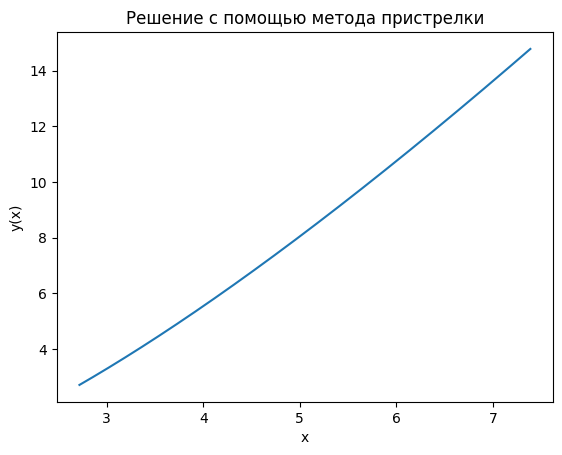

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# y[0] = y, y[1] = v
def shooting_function(x, y, p):
    '''
    The function returns the right-hand sides of two Cauchy problems
    '''
    if x <= 1 or np.log(x) <= 0:
        sqrt_val = 0
        df_dv = 0
        df_dy = 0
    else:
        arg = (np.e / np.log(x)) * y[0]**2 + 1 / x**2 - (np.e**y[1]) * y[0]
        if arg < 0:
            sqrt_val = 0
            df_dv = 0
            df_dy = 0
        else:
            sqrt_val = np.sqrt(arg)
            df_dv = (np.e**y[1] * y[0] * 0.5) / sqrt_val
            df_dy = -((2 * np.e * y[0] / np.log(x) - np.e**y[1]) * 0.5) / sqrt_val
    y_system = np.array([y[1], sqrt_val])
    p_system = np.array([p[1], -df_dv * p[1] - df_dy * p[0]])
    
    return y_system, p_system

def get_solution(y0, p0, x_start, x_end, h):
    n_steps = int((x_end - x_start) // h) + 1
    x_points = np.linspace(x_start, x_end, n_steps)
    y_values = np.zeros((n_steps, 2))
    y_values[0] = y0
    for i in range(1, n_steps):
        x_current = x_points[i-1]
        y = y_values[i-1]
        k1 = shooting_function(x_current, y, p0)[0]
        k2 = shooting_function(x_current + h/2, y + (h/2)*k1, p0)[0]
        k3 = shooting_function(x_current + h/2, y + (h/2)*k2, p0)[0]
        k4 = shooting_function(x_current + h, y + h*k3, p0)[0]
        y_values[i] = y + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
    return x_points, y_values

def get_deriv(y0, p0, x_start, x_end, h):
    n_steps = int((x_end - x_start) // h) + 1
    x_points = np.linspace(x_start, x_end, n_steps)
    p_values = np.zeros((n_steps, 2))
    p_values[0] = p0
    y_temp = np.array(y0)
    
    for i in range(1, n_steps):
        x_current = x_points[i-1]
        p = p_values[i-1]
        y_rhs, p_rhs = shooting_function(x_current, y_temp, p)
        
        k1 = p_rhs
        k2 = shooting_function(x_current + h/2, y_temp, p + (h/2)*k1)[1]
        k3 = shooting_function(x_current + h/2, y_temp, p + (h/2)*k2)[1]
        k4 = shooting_function(x_current + h, y_temp, p + h*k3)[1]
        
        p_values[i] = p + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
        y_temp = y_temp + h * y_rhs
    
    return p_values[-1, 0]

x_start = 2.718
x_end = 7.389
h = 0.001

r0 = 1e-6
a0 = 1.0
y0 = [np.e, a0]
p0 = [0, 1]
target_points = [0.5, 1.0, 1.5, 2.0, 2.5]

i = 0
max_iter = 1000
while i < max_iter:
    x_points, y_full_solution = get_solution(y0, p0, x_start, x_end, h)
    y_end = y_full_solution[-1, 0]
    residual = y_end - 2 * np.e**2
    if abs(residual) < r0:
        print(f"Сошлось на итерации: {i}")
        print(f"α = {round(a0, 5)}")
        final_alpha = a0
        final_y_solution = y_full_solution
        break
    p_end = get_deriv(y0, p0, x_start, x_end, h)
    if abs(p_end) > 1e-8:
        a0 = a0 - residual / p_end
    else:
        a0 = a0 - 0.5 * residual
    y0 = [np.e, a0]
    i += 1

plt.plot(x_points, y_full_solution[:, 0])
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Решение с помощью метода пристрелки')
plt.show()
#result = [y_full_solution[i] for i in range(len(y_full_solution[:, 0])) if x_points[i] == 0.5 or x_points[i] == 1.0 or x_points[i] == 1.5 or x_points[i] == 2 or x_points[i] == 2.5]

**Метод квазилинеаризации**

Итерация 1: 1.461e-05
Итерация 2: 4.716e-08
Сходимость достигнута


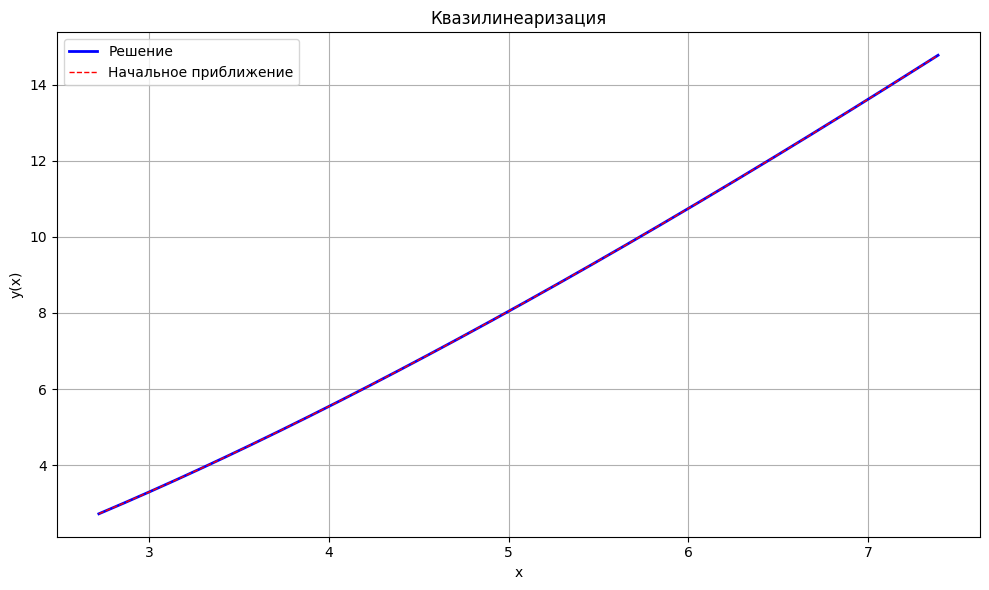

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Метод прогонки (Thomas algorithm)
def thomas_algorithm(a, b, c, d):
    n = len(d)
    alpha = np.zeros(n)
    beta = np.zeros(n)
    x = np.zeros(n)

    # Прямой ход
    alpha[0] = -c[0] / b[0]
    beta[0] = d[0] / b[0]

    for i in range(1, n - 1):
        denom = b[i] + a[i] * alpha[i - 1]
        alpha[i] = -c[i] / denom
        beta[i] = (d[i] - a[i] * beta[i - 1]) / denom

    # Обратный ход
    x[n - 1] = (d[n - 1] - a[n - 1] * beta[n - 2]) / (b[n - 1] + a[n - 1] * alpha[n - 2])
    for i in range(n - 2, -1, -1):
        x[i] = alpha[i] * x[i + 1] + beta[i]

    return x

def safe_exp(x, max_val=50.0):
    return np.exp(np.clip(x, -max_val, max_val))

def f_original(x, y, y_prime):
    eps = 1e-12
    log_x = np.where(np.abs(np.log(x)) < eps, eps, np.log(x))
    exp_term = safe_exp(y_prime)
    under_sqrt = 1.0 / x**2 + np.e * y**2 / log_x - y * exp_term
    return np.sqrt(np.maximum(under_sqrt, eps))

def f_y(x, y, y_prime):
    eps = 1e-12
    log_x = np.where(np.abs(np.log(x)) < eps, eps, np.log(x))
    exp_term = safe_exp(y_prime)
    under_sqrt = 1.0 / x**2 + np.e * y**2 / log_x - y * exp_term
    denominator = 2.0 * np.sqrt(np.maximum(under_sqrt, eps))
    numerator = 2.0 * np.e * y / log_x - exp_term
    return np.clip(numerator / denominator, -1e10, 1e10)

def f_y_prime(x, y, y_prime):
    eps = 1e-12
    log_x = np.where(np.abs(np.log(x)) < eps, eps, np.log(x))
    exp_term = safe_exp(y_prime)
    under_sqrt = 1.0 / x**2 + np.e * y**2 / log_x - y * exp_term
    denominator = 2.0 * np.sqrt(np.maximum(under_sqrt, eps))
    numerator = -y * exp_term
    return np.clip(numerator / denominator, -1e10, 1e10)

def g_n(x, y, y_prime):
    return f_original(x, y, y_prime) - f_y(x, y, y_prime) * y - f_y_prime(x, y, y_prime) * y_prime

# Решение линейной задачи методом прогонки
def linear_bvp_solve_sweep(p, q, r, x, y_left, y_right):
    N = len(x)
    h = x[1] - x[0]
    a = np.zeros(N)
    b = np.zeros(N)
    c = np.zeros(N)
    d = np.zeros(N)

    a[0], b[0], c[0], d[0] = 0, 1, 0, y_left
    a[-1], b[-1], c[-1], d[-1] = 0, 1, 0, y_right

    for i in range(1, N - 1):
        a[i] = 1.0 / h**2 - p[i] / (2.0 * h)
        b[i] = -2.0 / h**2 + q[i]
        c[i] = 1.0 / h**2 + p[i] / (2.0 * h)
        d[i] = r[i]

    return thomas_algorithm(a, b, c, d)

# Метод квазилинеаризации
def quasilinear_solve(N=200, tol=1e-10, max_iter=10000):
    a, b = np.e, np.e**2
    y_a, y_b = np.e, 2 * np.e**2
    x = np.linspace(a, b, N)
    h = x[1] - x[0]

    # Начальное приближение
    y = x * np.log(x)

    for it in range(max_iter):
        y_prime = np.gradient(y, h)
        p = -f_y_prime(x, y, y_prime)
        q = -f_y(x, y, y_prime)
        r = g_n(x, y, y_prime)

        y_new = linear_bvp_solve_sweep(p, q, r, x, y_a, y_b)
        diff_norm = np.linalg.norm(y_new - y, np.inf)

        print(f"Итерация {it+1}: {diff_norm:.3e}")
        if diff_norm < tol:
            y = y_new
            print("Сходимость достигнута")
            break
        y = y_new

    return x, y


x_result, y_result = quasilinear_solve(N=200, tol=1e-6)
plt.figure(figsize=(10, 6))
plt.plot(x_result, y_result, 'b-', linewidth=2, label='Решение')
plt.plot(x_result, x_result * np.log(x_result), 'r--', linewidth=1, label='Начальное приближение')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Квазилинеаризация')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Задача номер Т5

Параметры:
  μ = 0.012277471
  η = 0.987722529
  Период T = 17.065216560157964
  Время интегрирования = 102.39129936094778
  Начальный шаг = 1e-06
  Требуемая точность ε = 1e-14
  Начальное состояние: x=0.994, y=0.0
  Начальные скорости: u=0.0, v=-2.0015851063790824
Статистика решения:
  Принято шагов: 34728
  Отклонено шагов: 0
  Всего шагов: 34728
  Минимальный шаг: 1.00e-10
  Максимальный шаг: 1.71e+00
  Количество точек решения: 34729
  Время начала: 0.0
  Время конца: 102.39129936094778


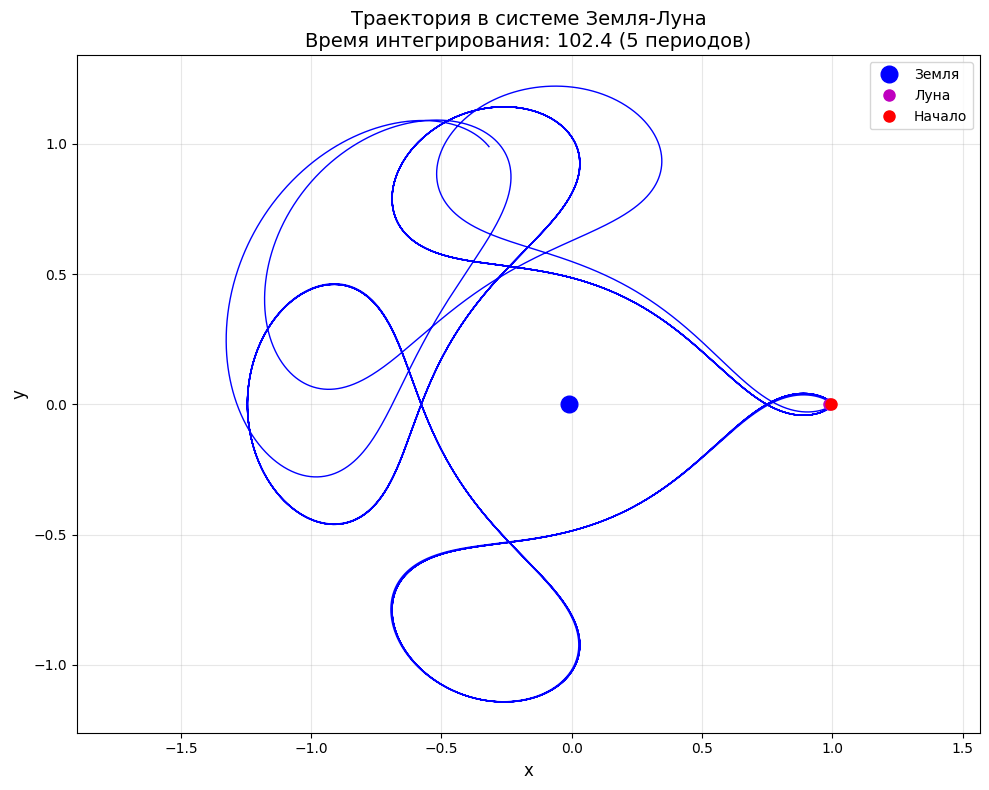

In [6]:
import numpy as np
from typing import List, Tuple, Callable, Any
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class State:
    """Состояние системы"""
    x: np.ndarray
    t: float

class RHS:
    """Правая часть системы ОДУ для ограниченной задачи трех тел"""
    def __init__(self, mu: float):
        self.mu = float(mu)
        self.eta = 1.0 - self.mu
    
    def __call__(self, t: float, x: np.ndarray) -> np.ndarray:
        """
        Вычисление правой части системы ОДУ
        x = [x, u, y, v]
        где: u = dx/dt, v = dy/dt
        """
        x0, x1, x2, x3 = x  # x0 = x, x1 = u, x2 = y, x3 = v
        
        # Вычисление A и B
        a_sq = (x0 + self.mu)**2 + x2**2
        b_sq = (x0 - self.eta)**2 + x2**2
        
        A = np.sqrt(a_sq * a_sq * a_sq)
        B = np.sqrt(b_sq * b_sq * b_sq)  
        
        # Правые части уравнений
        dx0_dt = x1
        dx1_dt = x0 + 2*x3 - self.eta*(x0 + self.mu)/A - self.mu*(x0 - self.eta)/B
        dx2_dt = x3
        dx3_dt = x2 - 2*x1 - self.eta*x2/A - self.mu*x2/B
        
        return np.array([dx0_dt, dx1_dt, dx2_dt, dx3_dt], dtype=np.float64)

class DP5:
    """Метод Дормана-Принса 5-го порядка с автоматическим выбором шага"""
    
    # Коэффициенты метода Дормана-Принса 5-го порядка
    a = np.array([
        [0, 0, 0, 0, 0, 0],
        [1/5, 0, 0, 0, 0, 0],
        [3/40, 9/40, 0, 0, 0, 0],
        [44/45, -56/15, 32/9, 0, 0, 0],
        [19372/6561, -25360/2187, 64448/6561, -212/729, 0, 0],
        [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, 0],
        [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84]
    ], dtype=np.float64)
    
    b5 = np.array([35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0], dtype=np.float64)
    b4 = np.array([5179/57600, 0, 7571/16695, 393/640, -92097/339200, 187/2100, 1/40], dtype=np.float64)
    
    c = np.array([0, 1/5, 3/10, 4/5, 8/9, 1, 1], dtype=np.float64)
    
    def __init__(self, eps: float = 1e-14, safety_factor: float = 0.9, 
                 min_step: float = 1e-10, max_step: float = 1.0):
        """
        Инициализация метода DP5
        
        Parameters:
        eps : float
            Заданная точность
        safety_factor : float
            Коэффициент безопасности для выбора шага
        min_step : float
            Минимальный допустимый шаг
        max_step : float
            Максимальный допустимый шаг
        """
        self.eps = eps
        self.safety_factor = safety_factor
        self.min_step = min_step
        self.max_step = max_step
    
    def step(self, rhs: Callable, t: float, x: np.ndarray, h: float) -> Tuple[np.ndarray, np.ndarray, float]:
        """
        Один шаг метода DP5
        
        Returns:
        x_new : np.ndarray
            Новое приближение 5-го порядка
            #x_err : np.ndarray
            Разность между приближениями 5-го и 4-го порядка -- ошибка шага
        err : float
            Оценка ошибки
        """
        # Вычисление k_i
        k = np.zeros((7, len(x)), dtype=np.float64)
        
        for i in range(7):
            sum_a = np.zeros_like(x)
            for j in range(i):
                sum_a += self.a[i, j] * k[j]
            
            k[i] = rhs(t + self.c[i] * h, x + h * sum_a)
        
        # Приближение 5-го порядка
        sum_b5 = np.zeros_like(x)
        for i in range(7):
            sum_b5 += self.b5[i] * k[i]
        x5 = x + h * sum_b5
        
        # Приближение 4-го порядка
        sum_b4 = np.zeros_like(x)
        for i in range(7):
            sum_b4 += self.b4[i] * k[i]
        x4 = x + h * sum_b4
        
        # Оценка ошибки
        error = np.linalg.norm(x5 - x4, np.inf)
        
        return x5, error
    
    def solve(self, rhs: RHS, initial_state: State, end_time: float, 
              initial_step: float = 1e-3) -> List[State]:
        """
        Решение системы ОДУ методом DP5
        
        Parameters:
        rhs : RHS
            Правая часть системы ОДУ
        initial_state : State
            Начальное состояние
        end_time : float
            Конечное время
        initial_step : float
            Начальный шаг интегрирования
            
        Returns:
        solution : List[State]
            Список состояний системы
        """
        solution = [initial_state]
        t = initial_state.t
        x = initial_state.x.copy()
        h = initial_step
        
        # Статистика
        steps_accepted = 0
        steps_rejected = 0
        
        while t < end_time:
            # Коррекция шага
            if t + h > end_time:
                h = end_time - t
            
            # шаг
            x_new, error = self.step(rhs, t, x, h)
            
            # точность
            if error <= self.eps:
                t += h
                x = x_new
                solution.append(State(x.copy(), t))
                steps_accepted += 1
                
                # Адаптация шага
                if error > 0:
                    h_new = h * self.safety_factor * (self.eps / error)**0.2
                else:
                    h_new = h * 2.0  # если ошибка нулевая, увеличиваем шаг
                
                h = np.clip(h_new, self.min_step, self.max_step)
            else:
                h_new = h * self.safety_factor * (self.eps / error)**0.25
                h = max(h_new, self.min_step)
                steps_rejected += 1
        
        print(f"Статистика решения:")
        print(f"  Принято шагов: {steps_accepted}")
        print(f"  Отклонено шагов: {steps_rejected}")
        print(f"  Всего шагов: {steps_accepted + steps_rejected}")
        print(f"  Минимальный шаг: {self.min_step:.2e}")
        print(f"  Максимальный шаг: {self.max_step:.2e}")
        
        return solution

def main():
    """Основная функция"""
    # Параметры задачи
    mu = 0.012277471
    T = 17.0652165601579625588917206249
    
    # Начальные условия
    initial_state = State(
        x=np.array([0.994, 0.0, 0.0, -2.00158510637908252240537862224], dtype=np.float64),
        t=0.0
    )
    
    # Параметры интегрирования
    end_time = 6 * T
    initial_step = 1e-6
    eps = 1e-14
    
    print(f"Параметры:")
    print(f"  μ = {mu}")
    print(f"  η = {1 - mu}")
    print(f"  Период T = {T}")
    print(f"  Время интегрирования = {end_time}")
    print(f"  Начальный шаг = {initial_step}")
    print(f"  Требуемая точность ε = {eps}")
    print(f"  Начальное состояние: x={initial_state.x[0]}, y={initial_state.x[2]}")
    print(f"  Начальные скорости: u={initial_state.x[1]}, v={initial_state.x[3]}")
    
    # Создаем правую часть
    rhs = RHS(mu)
    
    # Создаем решатель DP5
    dp5 = DP5(eps=eps, min_step=1e-10, max_step=0.1*T)
    
    # Решаем систему
    solution = dp5.solve(rhs, initial_state, end_time, initial_step)
    print(f"  Количество точек решения: {len(solution)}")
    print(f"  Время начала: {solution[0].t}")
    print(f"  Время конца: {solution[-1].t}")
    
    t_vals = [s.t for s in solution]
    x_vals = [s.x[0] for s in solution]
    y_vals = [s.x[2] for s in solution]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(x_vals, y_vals, 'b-', linewidth=1)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(f'Траектория в системе Земля-Луна\nВремя интегрирования: {end_time:.1f} (5 периодов)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    ax.plot(-mu, 0, 'bo', markersize=12, label='Земля')
    ax.plot(1-mu, 0, 'mo', markersize=8, label='Луна')
    
    ax.plot(x_vals[0], y_vals[0], 'ro', markersize=8, label='Начало')
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()